In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

# Project root (launch Jupyter from the repository root)
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "train_FD001.txt"



In [6]:
columns = (
    ["engine_id", "cycle"]
    + [f"setting_{i}" for i in range(1, 4)]
    + [f"sensor_{i}" for i in range(1, 22)]
)

df = pd.read_csv(
    DATA_PATH,
    sep=r"\s+",
    header=None,
    names=columns
)

df.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


Engine lifetime statistics:
count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64


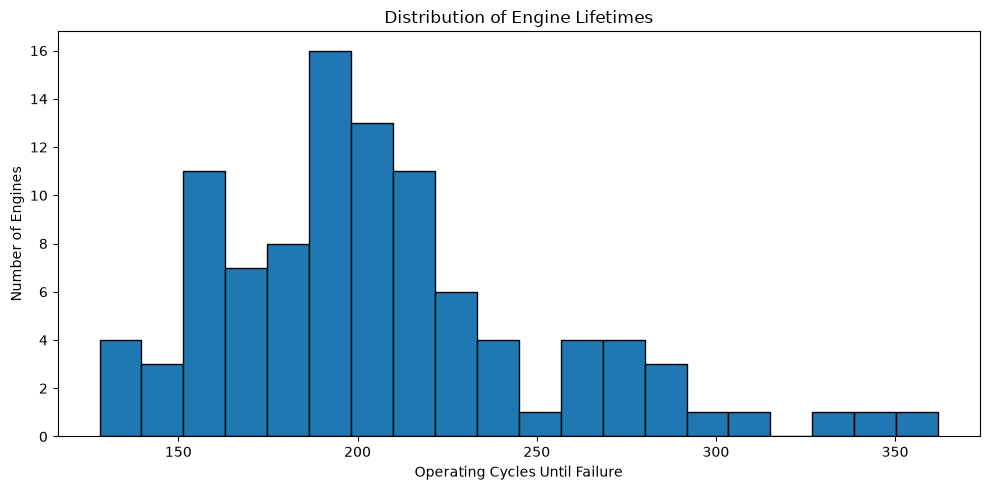

In [7]:
# Maximum operating cycle for each engine
engine_lifetimes = df.groupby("engine_id")["cycle"].max()

print("Engine lifetime statistics:")
print(engine_lifetimes.describe())

# Plot engine lifetime distribution
plt.figure(figsize=(10, 5))

plt.hist(
    engine_lifetimes,
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Engine Lifetimes")
plt.xlabel("Operating Cycles Until Failure")
plt.ylabel("Number of Engines")

plt.tight_layout()
plt.show()

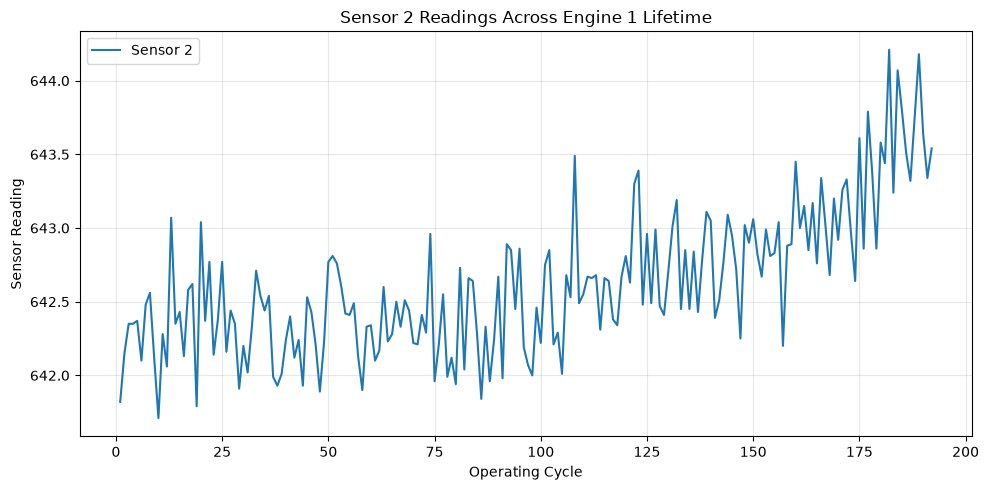

In [8]:
# Select Engine 1
engine_1 = df[df["engine_id"] == 1]

plt.figure(figsize=(10, 5))

plt.plot(
    engine_1["cycle"],
    engine_1["sensor_2"],
    label="Sensor 2"
)

plt.title("Sensor 2 Readings Across Engine 1 Lifetime")
plt.xlabel("Operating Cycle")
plt.ylabel("Sensor Reading")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()